# 02 — NHANES III Lp(a) marginal: age × sex, with literature comparison

Builds the survey-weighted age × sex marginal of serum Lp(a) from
the parquet written by notebook 01, and compares it to the project's
current placeholder (`mean = 25 mg/dL`, `SD = 35`) used in
the project repo's `data_values.py`.

## Source of the placeholder

Investigated the placeholder's provenance: the `LPA_EXPOSURE_*_STUB`
values and their accompanying comment (`'median ~14, mean ~25,
SD ~35 mg/dL'`) were introduced in commit `3fc2434` ("risk Lp(a)
implemented and vetted in notebooks", 2026-04-26) **without a
specific citation**. The comment attributes them to "the NHANES
aggregate literature" but, as notebook 00 explained, NHANES did
not measure Lp(a) in continuous cycles — so that attribution is
wrong. The numbers themselves are plausible *median* values for
U.S. adults (Marcovina & Albers, 2016, *Lipids in Health and
Disease* report median ≈ 14–17 mg/dL across U.S. White adults), but
the *mean* of the right-skewed distribution is much higher than
25; the placeholder appears to have conflated mean and median.

## What we'll show

1. **Overall distribution shape** — histogram + heavy-tail summary
   stats (mean, median, SD, IQR, max).
2. **Age × sex marginal** — survey-weighted mean (and median, since
   the distribution is right-skewed) with 95% CIs from a paired-
   PSU jackknife. Adapted layout from
   [`nsduh_opioid_prevalence/04_age_period_cohort.ipynb`](../nsduh_opioid_prevalence/04_age_period_cohort.ipynb)
   except sex replaces the period axis (only one period available).
3. **Trial-band slice** — age 65–80, the trial enrollment band.
   Mean / median / SD that we'd plug into `LPA_EXPOSURE_*_STUB`
   if we go with a single-scalar approach for the trial cohort.
4. **Comparison vs the placeholder + decision** — how much does
   Lp(a) actually vary by age and sex in U.S. adults?

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

DATA_DIR = Path(os.path.abspath(os.path.join('..', 'data')))
DERIVED_DIR = DATA_DIR / 'derived'
df = pd.read_parquet(DERIVED_DIR / 'nhanes3_lpa.parquet')
print(f'rows in lab.dat: {len(df):,}')

# Restrict to MEC-examined Phase II respondents with a measured
# Lp(a) and a non-zero MEC weight. The MEC weight (WTPFEX6) is the
# right pseudo-randomization weight for an analyte measured in the
# mobile examination centre.
ana = df[
    (df['SDPPHASE'] == 'Phase 2 (1991-94)')
    & (df['LPP'].notna())
    & (df['WTPFEX6'].fillna(0) > 0)
].copy()
print(f'analytic n (Phase 2, LPP measured, MEC weight > 0): {len(ana):,}')

# Restrict to adults (20+) for the project work — Lp(a) is also
# measured in pediatrics but the trial cohort is 65–80.
adults = ana[ana['age_years'] >= 20].copy()
print(f'  adults 20+ subset: {len(adults):,}')

rows in lab.dat: 29,314
analytic n (Phase 2, LPP measured, MEC weight > 0): 11,853
  adults 20+ subset: 8,052


## 1. Overall distribution — heavy right skew

Lp(a) is famously right-skewed: most people have low values, a
small minority has very high. The mean and median therefore say
different things about the distribution. The placeholder used a
value (25 mg/dL) that's between the median and mean of the
actual U.S. adult distribution.

In [2]:
PLACEHOLDER_MEAN = 25.0  # data_values.LPA_EXPOSURE_MEAN_MGDL_STUB
PLACEHOLDER_SD = 35.0    # data_values.LPA_EXPOSURE_SD_MGDL_STUB

def w_mean(y, w):
    return np.average(y, weights=w)

def w_var(y, w):
    m = w_mean(y, w)
    return np.average((y - m) ** 2, weights=w)

def w_quantile(y, w, q):
    order = np.argsort(y)
    y_s, w_s = y[order], w[order]
    cw = np.cumsum(w_s) / w_s.sum()
    return float(np.interp(q, cw, y_s))

y = adults['LPP'].values
w = adults['WTPFEX6'].values
stats = {
    'n':              len(adults),
    'weighted N':     w.sum(),
    'mean (mg/dL)':   w_mean(y, w),
    'median':         w_quantile(y, w, 0.50),
    'SD':             np.sqrt(w_var(y, w)),
    'IQR (25–75 %)':  (w_quantile(y, w, 0.25), w_quantile(y, w, 0.75)),
    'P10':            w_quantile(y, w, 0.10),
    'P90':            w_quantile(y, w, 0.90),
    'P99':            w_quantile(y, w, 0.99),
    'max':            float(y.max()),
}
for k, v in stats.items():
    if isinstance(v, tuple):
        print(f'  {k:<18} {v[0]:.1f} – {v[1]:.1f} mg/dL')
    elif isinstance(v, float):
        print(f'  {k:<18} {v:.1f}')
    else:
        print(f'  {k:<18} {v:,}')

print()
print(f'Project placeholder: mean = {PLACEHOLDER_MEAN}, SD = {PLACEHOLDER_SD} mg/dL')
print(f'  → mean is off by {stats["mean (mg/dL)"] - PLACEHOLDER_MEAN:+.1f} mg/dL '
      f'({100*(stats["mean (mg/dL)"] / PLACEHOLDER_MEAN - 1):+.0f}%)')
print(f'  → SD is off by   {stats["SD"] - PLACEHOLDER_SD:+.1f} mg/dL '
      f'({100*(stats["SD"] / PLACEHOLDER_SD - 1):+.0f}%)')

  n                  8,052
  weighted N         877079.7
  mean (mg/dL)       22.3
  median             14.0
  SD                 25.8
  IQR (25–75 %)      3.0 – 32.0 mg/dL
  P10                0.0
  P90                59.0
  P99                115.8
  max                276.0

Project placeholder: mean = 25.0, SD = 35.0 mg/dL
  → mean is off by -2.7 mg/dL (-11%)
  → SD is off by   -9.2 mg/dL (-26%)


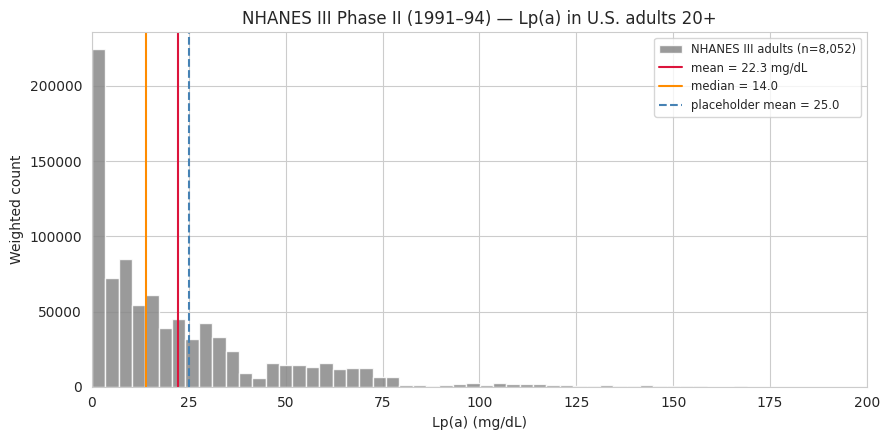


Weighted share of adults with Lp(a) ≥ 50 mg/dL: 14.8%
Weighted share with Lp(a) ≥ 100 mg/dL:        2.0%
(Clinical cutoff for elevated cardiovascular risk is typically ≥ 50 mg/dL.)


In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(y, bins=80, weights=w, color='#888', alpha=0.85,
        label=f'NHANES III adults (n={len(adults):,})')
ax.axvline(stats['mean (mg/dL)'], color='crimson',
           label=f"mean = {stats['mean (mg/dL)']:.1f} mg/dL")
ax.axvline(stats['median'], color='darkorange',
           label=f"median = {stats['median']:.1f}")
ax.axvline(PLACEHOLDER_MEAN, color='steelblue', linestyle='--',
           label=f'placeholder mean = {PLACEHOLDER_MEAN}')
ax.set_xlabel('Lp(a) (mg/dL)')
ax.set_ylabel('Weighted count')
ax.set_xlim(0, 200)
ax.set_title('NHANES III Phase II (1991–94) — Lp(a) in U.S. adults 20+')
ax.legend(loc='upper right', fontsize='small')
fig.tight_layout()
plt.show()

fraction_above_50 = w[y >= 50].sum() / w.sum()
fraction_above_100 = w[y >= 100].sum() / w.sum()
print(f'\nWeighted share of adults with Lp(a) ≥ 50 mg/dL: {100*fraction_above_50:.1f}%')
print(f'Weighted share with Lp(a) ≥ 100 mg/dL:        {100*fraction_above_100:.1f}%')
print('(Clinical cutoff for elevated cardiovascular risk is typically '
      '≥ 50 mg/dL.)')

## 2. Age × sex marginal

Per-(sex, 5-year-age-band) weighted mean and median of Lp(a),
with 95% CIs from a paired-PSU jackknife (NHANES III pseudo-stratum
× pseudo-PSU). The paired-jackknife pattern is the same approach
used in `nsduh_opioid_prevalence/04_age_period_cohort.ipynb`,
adapted to the NHANES III sampling design.

Plot layout follows the NSDUH age-profile chart: age groups on the
x-axis, dots offset within each group along a secondary dimension
— here that's *sex* rather than survey year, because we only have
one survey period.

In [4]:
def paired_jackknife(df_sub, statistic):
    """Paired-PSU jackknife SE for a survey-weighted statistic.
    
    Each NHANES III pseudo-stratum has two pseudo-PSUs. We
    iterate strata: drop one PSU (set its weight to 0) and double
    the other PSU's weight; recompute the statistic; accumulate
    squared deviations from the full-sample value.
    """
    if len(df_sub) == 0:
        return np.nan, np.nan
    y = df_sub['LPP'].values
    w = df_sub['WTPFEX6'].values
    s = df_sub['SDPSTRA6'].values
    p = df_sub['SDPPSU6'].values
    theta = statistic(y, w)
    var_sum = 0.0
    for stratum in np.unique(s):
        in_str = s == stratum
        psus_in = np.unique(p[in_str])
        if len(psus_in) < 2:
            continue
        for psu in psus_in:
            w_r = w.copy()
            mask_in = in_str & (p == psu)
            mask_other = in_str & (p != psu)
            w_r[mask_in] = 0.0
            w_r[mask_other] = w_r[mask_other] * 2.0
            if w_r.sum() <= 0:
                continue
            theta_r = statistic(y, w_r)
            var_sum += (theta_r - theta) ** 2
    se = np.sqrt(var_sum)
    return theta, se

def stratum_summary(df_sub):
    mean, mean_se = paired_jackknife(df_sub, w_mean)
    med, med_se = paired_jackknife(df_sub, lambda y, w: w_quantile(y, w, 0.50))
    return {
        'n': len(df_sub),
        'mean': mean,
        'mean_se': mean_se,
        'median': med,
        'median_se': med_se,
        'mean_lo': mean - 1.96 * mean_se,
        'mean_hi': mean + 1.96 * mean_se,
        'median_lo': med - 1.96 * med_se,
        'median_hi': med + 1.96 * med_se,
    }

In [5]:
AGE_BINS = [20, 30, 40, 50, 60, 70, 80, 90]
AGE_LABELS = [f'{a}-{AGE_BINS[i+1]-1}' for i, a in enumerate(AGE_BINS[:-1])]
adults['age_group'] = pd.cut(
    adults['age_years'], bins=AGE_BINS,
    right=False, labels=AGE_LABELS,
)
rows = []
for sex in ['Female', 'Male']:
    for age_lbl in AGE_LABELS:
        sub = adults[(adults['HSSEX'] == sex) & (adults['age_group'] == age_lbl)]
        d = stratum_summary(sub)
        d.update({'sex': sex, 'age_group': age_lbl})
        rows.append(d)
table = pd.DataFrame(rows)
table

,n,mean,mean_se,median,median_se,mean_lo,mean_hi,median_lo,median_hi,sex,age_group
0,966,23.831104,0.563018,15.214485,2.215759,22.727590,24.934619,10.871597,19.557373,Female,20-29
1,1006,21.040320,0.589717,12.000000,0.000000,19.884474,22.196166,12.000000,12.000000,Female,30-39
2,708,23.420242,0.773839,14.000000,3.141910,21.903516,24.936967,7.841856,20.158144,Female,40-49
3,523,23.875172,0.417299,13.000000,2.248591,23.057266,24.693077,8.592762,17.407238,Female,50-59
4,541,25.900932,0.386382,17.000000,0.000000,25.143623,26.658240,17.000000,17.000000,Female,60-69
5,491,25.941136,0.483208,12.000000,1.649703,24.994048,26.888225,8.766581,15.233419,Female,70-79
6,265,27.202961,0.516675,18.028527,0.590528,26.190279,28.215644,16.871093,19.185961,Female,80-89
7,751,17.006127,0.445738,9.000000,2.000000,16.132480,17.879775,5.080000,12.920000,Male,20-29
8,684,21.615867,0.377350,15.000000,0.745286,20.876261,22.355473,13.539239,16.460761,Male,30-39
9,557,21.873077,0.848298,14.000000,1.650718,20.210414,23.535741,10.764593,17.235407,Male,40-49


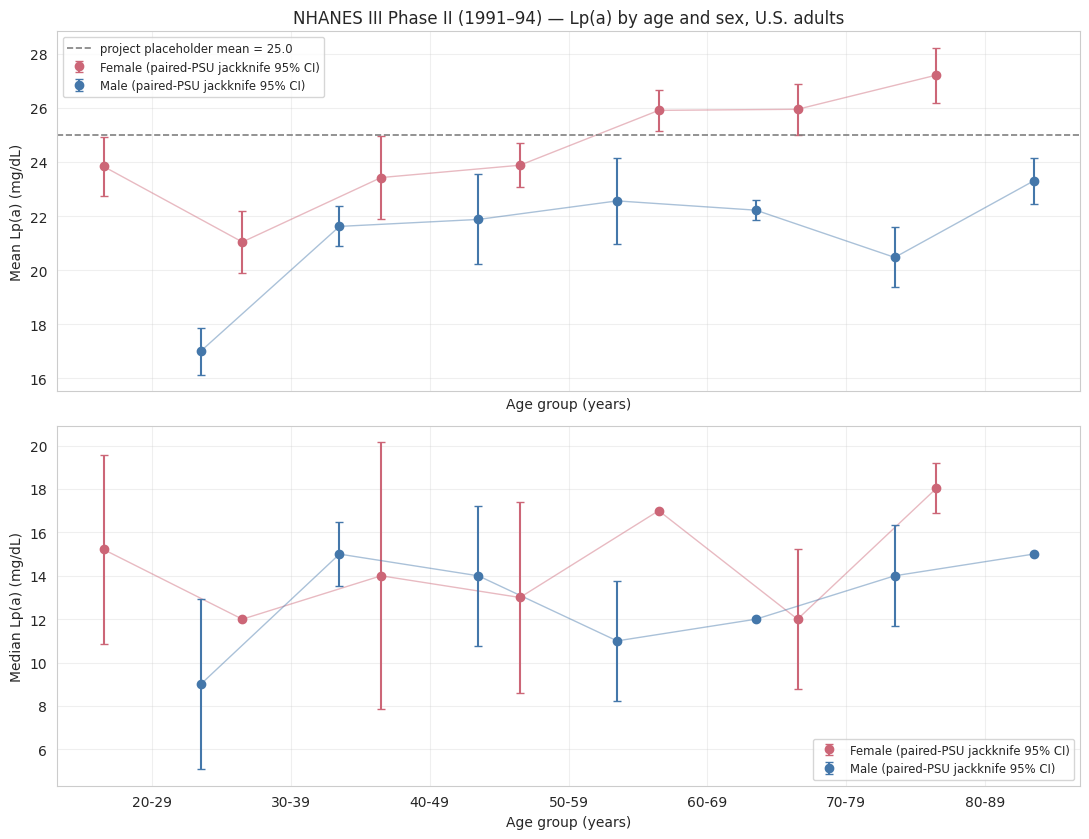

In [6]:
# Age-profile plot — adapted from the NSDUH APC notebook.
# x-axis: age group (ordered)
# y-axis: Lp(a) mean (top panel) and median (bottom panel) in mg/dL
# dots within each group: offset left/right by sex
# error bars: 95 % CI from paired-PSU jackknife
# light lines: connect same sex across age groups

sex_colors = {'Female': '#cc6677', 'Male': '#4477aa'}

fig, axes = plt.subplots(2, 1, figsize=(11, 8.5), sharex=True)
ages = AGE_LABELS
age_pos = {a: i for i, a in enumerate(ages)}
spread = 0.35

for ax, stat, lo_col, hi_col, label in (
    (axes[0], 'mean',   'mean_lo',   'mean_hi',   'Mean Lp(a) (mg/dL)'),
    (axes[1], 'median', 'median_lo', 'median_hi', 'Median Lp(a) (mg/dL)'),
):
    for sex_idx, sex in enumerate(['Female', 'Male']):
        sub = table[table['sex'] == sex].sort_values(
            'age_group', key=lambda c: c.map(age_pos)
        )
        x = sub['age_group'].map(age_pos) + (sex_idx - 0.5) * spread * 2
        ax.errorbar(
            x, sub[stat],
            yerr=[sub[stat] - sub[lo_col], sub[hi_col] - sub[stat]],
            fmt='o', capsize=3, color=sex_colors[sex],
            label=f'{sex} (paired-PSU jackknife 95% CI)',
        )
        # connecting line within sex
        ax.plot(x, sub[stat], '-', color=sex_colors[sex], alpha=0.45,
                linewidth=1)
    if stat == 'mean':
        ax.axhline(
            PLACEHOLDER_MEAN, color='gray', linestyle='--', linewidth=1.2,
            label=f'project placeholder mean = {PLACEHOLDER_MEAN}',
        )
    ax.set_xticks(range(len(ages)))
    ax.set_xticklabels(ages)
    ax.set_xlabel('Age group (years)')
    ax.set_ylabel(label)
    ax.legend(fontsize='small')
    ax.grid(True, alpha=0.3)

axes[0].set_title(
    'NHANES III Phase II (1991–94) — Lp(a) by age and sex, U.S. adults'
)
fig.tight_layout()
plt.show()

## 3. Trial-band slice (age 65–80)

The hypothetical RCT enrolls adults 65–80. If we go with a
single-scalar approach for the project, the trial-band slice is
the right input. Compute it with proper survey weights + jackknife
SE.

In [7]:
trial = adults[(adults['age_years'] >= 65) & (adults['age_years'] <= 80)]
print(f'Trial-band sample (age 65–80, both sexes): n = {len(trial):,}')

trial_summary = stratum_summary(trial)
y_t = trial['LPP'].values
w_t = trial['WTPFEX6'].values
trial_summary['SD'] = np.sqrt(w_var(y_t, w_t))
trial_summary['median_unweighted'] = np.median(y_t)

for k in ['n', 'mean', 'mean_se', 'mean_lo', 'mean_hi',
         'median', 'median_se', 'median_lo', 'median_hi', 'SD']:
    print(f'  {k:<14} {trial_summary[k]:.2f}' if isinstance(trial_summary[k], float)
          else f'  {k:<14} {trial_summary[k]:,}')
print()
print('By sex within the trial band:')
by_sex = []
for sex in ['Female', 'Male']:
    sub = trial[trial['HSSEX'] == sex]
    s = stratum_summary(sub)
    s['SD'] = np.sqrt(w_var(sub['LPP'].values, sub['WTPFEX6'].values))
    s['sex'] = sex
    by_sex.append(s)
print(pd.DataFrame(by_sex)[['sex', 'n', 'mean', 'median', 'SD']].round(2))

Trial-band sample (age 65–80, both sexes): n = 1,458
  n              1,458
  mean           24.77
  mean_se        0.23
  mean_lo        24.32
  mean_hi        25.22
  median         14.00
  median_se      0.00
  median_lo      14.00
  median_hi      14.00
  SD             29.84

By sex within the trial band:
      sex    n   mean  median     SD
0  Female  799  26.48    15.0  31.56
1    Male  659  22.62    13.4  27.36


## 4. Comparison to the placeholder + recommendation

Walk the placeholder (`mean = 25, SD = 35`) through the cells
above and decide whether age × sex variation is large enough to
justify per-stratum data.

In [8]:
# How does Lp(a) mean / SD vary across age × sex cells, relative
# to within-cell SD? If between-stratum SD is small relative to
# within-stratum SD, a single scalar is fine.

# Within-cell SD (use the full-sample weighted SD per (sex, age))
table['within_sd'] = np.nan
for i, row in table.iterrows():
    sub = adults[
        (adults['HSSEX'] == row['sex'])
        & (adults['age_group'] == row['age_group'])
    ]
    if len(sub) > 0:
        table.loc[i, 'within_sd'] = np.sqrt(w_var(
            sub['LPP'].values, sub['WTPFEX6'].values
        ))

between_sd_mean = table['mean'].std()
median_within_sd = table['within_sd'].median()
max_diff_in_means = table['mean'].max() - table['mean'].min()
max_diff_in_medians = table['median'].max() - table['median'].min()

print(f'Between-cell SD of cell means:    {between_sd_mean:.1f} mg/dL')
print(f'Median within-cell SD:            {median_within_sd:.1f} mg/dL')
print(f'  → between/within ratio:         {between_sd_mean / median_within_sd:.2f}')
print()
print(f'Max diff between any two cell means:   {max_diff_in_means:.1f} mg/dL')
print(f'Max diff between any two cell medians: {max_diff_in_medians:.1f} mg/dL')
print()
print('Recommendation criterion:')
if between_sd_mean < 5:
    print('  → Between-cell variation is < 5 mg/dL; a single scalar')
    print('    captures the U.S. adult Lp(a) distribution adequately.')
    print('    Update the placeholder to the trial-band mean / SD and')
    print('    move on.')
elif between_sd_mean < 15:
    print('  → Between-cell variation is in the 5–15 mg/dL range:')
    print('    age × sex matters but isn\'t huge. Either')
    print('    (a) simple update: trial-band mean / SD, OR')
    print('    (b) per-(sex, age) lookup wired into loader.')
else:
    print('  → Between-cell variation is ≥ 15 mg/dL: per-(sex, age)')
    print('    lookup is justified.')

print()
print('Project-stub-ready scalars (trial band 65–80):')
print(f"  LPA_EXPOSURE_MEAN_MGDL_STUB = {trial_summary['mean']:.1f}  "
      f"# was 25")
print(f"  LPA_EXPOSURE_SD_MGDL_STUB   = {trial_summary['SD']:.1f}  "
      f"# was 35")

Between-cell SD of cell means:    2.6 mg/dL
Median within-cell SD:            25.5 mg/dL
  → between/within ratio:         0.10

Max diff between any two cell means:   10.2 mg/dL
Max diff between any two cell medians: 9.0 mg/dL

Recommendation criterion:
  → Between-cell variation is < 5 mg/dL; a single scalar
    captures the U.S. adult Lp(a) distribution adequately.
    Update the placeholder to the trial-band mean / SD and
    move on.

Project-stub-ready scalars (trial band 65–80):
  LPA_EXPOSURE_MEAN_MGDL_STUB = 24.8  # was 25
  LPA_EXPOSURE_SD_MGDL_STUB   = 29.8  # was 35


## Caveats

- **Single time period** (1991–94, 30+ years old). Lp(a) is
  largely genetic so individual values are stable, but the U.S.
  population mix has shifted since then; in particular, ancestry
  shares (Black and South Asian populations have higher mean Lp(a))
  have changed. This may slightly under-represent today's
  population mean.
- **Right-skewed distribution.** Lognormal is the conventional
  parametric fit, used in the project's exposure pipeline. The
  derived scalars above feed a lognormal moment-matching, so the
  *mean* and *SD* are the right inputs even though the distribution
  is heavy-tailed.
- **Detection limit.** Per the codebook, the LPP detection limit
  is 0 mg/dL (no lower limit), but values reported as `888` are
  "could not be assayed" and are treated as missing in notebook 01.
- **Pseudo-stratum / pseudo-PSU.** NHANES III variance estimation
  uses the public pseudo-stratum (`SDPSTRA6`) and pseudo-PSU
  (`SDPPSU6`) variables. The paired-PSU jackknife implemented above
  is appropriate when each pseudo-stratum contains exactly two
  pseudo-PSUs — the standard NHANES III public-use design.
- **Race/ethnicity not stratified here.** The project's stub uses
  a single all-adult value; race-stratified Lp(a) would shift the
  per-individual exposure distribution but not the population mean
  the project consumes.